<a href="https://colab.research.google.com/github/DHARSHINIKANDASAMY/ResearchPaper_project/blob/main/P3a1(muril_model).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q transformers sentencepiece accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.9 MB/s eta 0:00:00


In [ ]:
import os
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModel

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device :", device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Using Device : cuda
Tesla T4


In [ ]:
SEED = 42

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

torch.cuda.manual_seed_all(SEED)

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train_path = "/content/drive/MyDrive/FIRE2026/train_processed.csv"

dev_path = "/content/drive/MyDrive/FIRE2026/dev_processed.csv"

train_df = pd.read_csv(train_path)

dev_df = pd.read_csv(dev_path)

print("Training Samples :", len(train_df))

print("Validation Samples :", len(dev_df))

Training Samples : 4536
Validation Samples : 1134


In [ ]:
train_df = train_df[["claim", "evidence", "label"]]

dev_df = dev_df[["claim", "evidence", "label"]]

In [ ]:
train_df.head()

,claim,evidence,label
0,ममता बनर्जी ने किसी भी मंत्री को पद से नहीं हट...,पश्चिम बंगाल की मुख्यमंत्री ममता बनर्जी ने राज...,0
1,প্রতি ঘণ্টায় চাই হোম কোয়ারেন্টাইনদের ভিডিও! ...,কর্ণাটক সরকারের নয়া সিদ্ধান্ত। কোয়ারেন্টাইনে...,0
2,"করোনা সংক্রমণের আতঙ্ক, ভিনরাজ্যে কর্মরত যুবককে...","জানা গিয়েছে, বালুরঘাট থানার বোল্লা আদিবাসী পা...",1
3,जम्मू-कश्मीर में हालात सुधारने और शांति वापस ल...,कांग्रेस ने जम्मू-कश्मीर में बिगड़ते हालात और ...,1
4,It's immaterial whether Rahul or Modi becomes ...,Delhi Chief Minister Arvind Kejriwal on Friday...,1


In [ ]:
MODEL_NAME = "google/muril-base-cased"

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/3.16M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

In [ ]:
sample_claim = train_df.iloc[0]["claim"]

sample_evidence = train_df.iloc[0]["evidence"]

encoding = tokenizer(
    sample_claim,
    sample_evidence,
    truncation=True,
    padding="max_length",
    max_length=256
)

print(encoding.keys())

KeysView({'input_ids': [104, 32657, 57087, 1169, 1702, 1179, 4468, 1125, 5193, 1124, 1254, 89703, 119, 7254, 2056, 1125, 1856, 4054, 172530, 1154, 5367, 4567, 1126, 12896, 1447, 492, 105, 2671, 8362, 1117, 5094, 32657, 57087, 1169, 1465, 1558, 1110, 1855, 55056, 1125, 1856, 19630, 1124, 26319, 1447, 1115, 119, 4169, 7389, 2559, 7249, 2759, 7113, 1125, 11783, 2084, 1123, 17987, 22674, 1117, 18018, 2084, 3280, 1587, 1681, 1115, 492, 25400, 1110, 1621, 119, 57087, 1169, 1974, 55056, 1124, 2759, 1110, 23598, 14353, 1154, 4245, 20772, 1292, 1125, 1539, 1115, 119, 8310, 5402, 121840, 1117, 131550, 9831, 1125, 1123, 129805, 5022, 1587, 6559, 492, 1233, 10791, 2759, 1110, 10327, 8079, 77543, 1126, 6492, 3977, 1587, 1681, 1115, 119, 2843, 11460, 49299, 1123, 3442, 25613, 1125, 33661, 2095, 1747, 1115, 492, 1228, 9546, 1124, 1558, 1123, 2759, 2512, 1110, 38972, 1114, 91853, 19628, 1117, 14698, 1115, 492, 105, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [ ]:
class ClaimVerificationDataset(Dataset):

    def __init__(self, dataframe, tokenizer, max_length=256):

        self.data = dataframe

        self.tokenizer = tokenizer

        self.max_length = max_length

    def __len__(self):

        return len(self.data)

    def __getitem__(self, index):

        claim = str(self.data.iloc[index]["claim"])

        evidence = str(self.data.iloc[index]["evidence"])

        label = int(self.data.iloc[index]["label"])

        encoding = self.tokenizer(

            claim,

            evidence,

            max_length=self.max_length,

            padding="max_length",

            truncation=True,

            return_tensors="pt"

        )

        return {

            "input_ids": encoding["input_ids"].squeeze(0),

            "attention_mask": encoding["attention_mask"].squeeze(0),

            "label": torch.tensor(label, dtype=torch.long)

        }

In [ ]:
train_dataset = ClaimVerificationDataset(

    train_df,

    tokenizer

)

dev_dataset = ClaimVerificationDataset(

    dev_df,

    tokenizer

)

In [ ]:
BATCH_SIZE = 8

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True

)

dev_loader = DataLoader(

    dev_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False

)

In [ ]:
batch = next(iter(train_loader))

print(batch.keys())

dict_keys(['input_ids', 'attention_mask', 'label'])


In [ ]:
print(batch["input_ids"].shape)

print(batch["attention_mask"].shape)

print(batch["label"].shape)

torch.Size([8, 256])
torch.Size([8, 256])
torch.Size([8])


part2

In [ ]:
muril = AutoModel.from_pretrained(MODEL_NAME)

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  953MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: google/muril-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
print(muril.config.hidden_size)

768


In [ ]:
class MuRILClassifier(nn.Module):

    def __init__(self):

        super(MuRILClassifier, self).__init__()

        self.muril = AutoModel.from_pretrained(MODEL_NAME)

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(768, 2)

    def forward(self, input_ids, attention_mask):

        outputs = self.muril(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls_embedding = outputs.last_hidden_state[:, 0, :]
#cls_embedding = outputs.pooler_output ------try instead of this above line
        x = self.dropout(cls_embedding)

        logits = self.fc(x)

        return logits

In [ ]:
model = MuRILClassifier()

model = model.to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: google/muril-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
print(model)

MuRILClassifier(
  (muril): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(197285, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise

In [ ]:
criterion = nn.CrossEntropyLoss()

In [ ]:
optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=2e-5,

    weight_decay=0.01

)

In [ ]:
from transformers import get_linear_schedule_with_warmup

In [ ]:
EPOCHS = 3

total_steps = len(train_loader) * EPOCHS

In [ ]:
scheduler = get_linear_schedule_with_warmup(

    optimizer,

    num_warmup_steps=0,

    num_training_steps=total_steps

)

In [ ]:
batch = next(iter(train_loader))

input_ids = batch["input_ids"].to(device)

attention_mask = batch["attention_mask"].to(device)

outputs = model(

    input_ids,

    attention_mask

)

print(outputs.shape)

torch.Size([8, 2])


In [ ]:
labels = batch["label"].to(device)

loss = criterion(outputs, labels)

print(loss.item())

0.6902451515197754


part3

In [ ]:
def train_epoch(model, dataloader, optimizer, scheduler, criterion, device):

    model.train()

    total_loss = 0

    predictions = []
    true_labels = []

    for batch in dataloader:

        input_ids = batch["input_ids"].to(device)

        attention_mask = batch["attention_mask"].to(device)

        labels = batch["label"].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        loss = criterion(outputs, labels)

        loss.backward()

        # Gradient Clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        scheduler.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)

        predictions.extend(preds.cpu().numpy())

        true_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader)

    accuracy = accuracy_score(true_labels, predictions)

    precision = precision_score(true_labels, predictions)

    recall = recall_score(true_labels, predictions)

    f1 = f1_score(true_labels, predictions)

    return avg_loss, accuracy, precision, recall, f1

In [ ]:
def evaluate(model, dataloader, criterion, device):

    model.eval()

    total_loss = 0

    predictions = []

    true_labels = []

    with torch.no_grad():

        for batch in dataloader:

            input_ids = batch["input_ids"].to(device)

            attention_mask = batch["attention_mask"].to(device)

            labels = batch["label"].to(device)

            outputs = model(

                input_ids=input_ids,

                attention_mask=attention_mask

            )

            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            predictions.extend(preds.cpu().numpy())

            true_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader)

    accuracy = accuracy_score(true_labels, predictions)

    precision = precision_score(true_labels, predictions)

    recall = recall_score(true_labels, predictions)

    f1 = f1_score(true_labels, predictions)

    return avg_loss, accuracy, precision, recall, f1

In [ ]:
best_f1 = 0

patience = 2

counter = 0

In [ ]:
history = {

    "train_loss": [],

    "val_loss": [],

    "train_acc": [],

    "val_acc": [],

    "train_f1": [],

    "val_f1": []

}

In [ ]:
for epoch in range(EPOCHS):

    print("=" * 60)

    print(f"Epoch {epoch+1}/{EPOCHS}")

    train_loss, train_acc, train_precision, train_recall, train_f1 = train_epoch(

        model,

        train_loader,

        optimizer,

        scheduler,

        criterion,

        device

    )

    val_loss, val_acc, val_precision, val_recall, val_f1 = evaluate(

        model,

        dev_loader,

        criterion,

        device

    )

    history["train_loss"].append(train_loss)

    history["val_loss"].append(val_loss)

    history["train_acc"].append(train_acc)

    history["val_acc"].append(val_acc)

    history["train_f1"].append(train_f1)

    history["val_f1"].append(val_f1)

    print(f"Train Loss : {train_loss:.4f}")

    print(f"Train Accuracy : {train_acc:.4f}")

    print(f"Train Precision : {train_precision:.4f}")

    print(f"Train Recall : {train_recall:.4f}")

    print(f"Train F1 : {train_f1:.4f}")

    print("-" * 40)

    print(f"Validation Loss : {val_loss:.4f}")

    print(f"Validation Accuracy : {val_acc:.4f}")

    print(f"Validation Precision : {val_precision:.4f}")

    print(f"Validation Recall : {val_recall:.4f}")

    print(f"Validation F1 : {val_f1:.4f}")

    if val_f1 > best_f1:

        best_f1 = val_f1

        counter = 0

        torch.save(

            model.state_dict(),

            "/content/drive/MyDrive/FIRE2026/muril_best_model.pth"

        )

        print("Best model saved!")

    else:

        counter += 1

        print(f"Early Stopping Counter : {counter}/{patience}")

        if counter >= patience:

            print("Early stopping triggered.")

            break

Epoch 1/3
Train Loss : 0.6347
Train Accuracy : 0.6702
Train Precision : 0.6702
Train Recall : 1.0000
Train F1 : 0.8025
----------------------------------------
Validation Loss : 0.6454
Validation Accuracy : 0.6534
Validation Precision : 0.6534
Validation Recall : 1.0000
Validation F1 : 0.7904
Best model saved!
Epoch 2/3
Train Loss : 0.6346
Train Accuracy : 0.6702
Train Precision : 0.6702
Train Recall : 1.0000
Train F1 : 0.8025
----------------------------------------
Validation Loss : 0.6454
Validation Accuracy : 0.6534
Validation Precision : 0.6534
Validation Recall : 1.0000
Validation F1 : 0.7904
Early Stopping Counter : 1/2
Epoch 3/3
Train Loss : 0.6346
Train Accuracy : 0.6702
Train Precision : 0.6702
Train Recall : 1.0000
Train F1 : 0.8025
----------------------------------------
Validation Loss : 0.6454
Validation Accuracy : 0.6534
Validation Precision : 0.6534
Validation Recall : 1.0000
Validation F1 : 0.7904
Early Stopping Counter : 2/2
Early stopping triggered.


part4

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [ ]:
model = MuRILClassifier()

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/FIRE2026/muril_best_model.pth",
        map_location=device
    )
)

model = model.to(device)

model.eval()

print("Best MuRIL Model Loaded Successfully!")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: google/muril-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Best MuRIL Model Loaded Successfully!


In [ ]:
all_predictions = []

all_labels = []

with torch.no_grad():

    for batch in dev_loader:

        input_ids = batch["input_ids"].to(device)

        attention_mask = batch["attention_mask"].to(device)

        labels = batch["label"].to(device)

        outputs = model(

            input_ids=input_ids,

            attention_mask=attention_mask

        )

        preds = torch.argmax(outputs, dim=1)

        all_predictions.extend(preds.cpu().numpy())

        all_labels.extend(labels.cpu().numpy())

In [ ]:
accuracy = accuracy_score(

    all_labels,

    all_predictions

)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.6534


In [ ]:
precision = precision_score(

    all_labels,

    all_predictions

)

print(f"Precision : {precision:.4f}")

Precision : 0.6534


In [ ]:
recall = recall_score(

    all_labels,

    all_predictions

)

print(f"Recall : {recall:.4f}")

Recall : 1.0000


In [ ]:
f1 = f1_score(

    all_labels,

    all_predictions

)

print(f"F1 Score : {f1:.4f}")

F1 Score : 0.7904


In [ ]:
print(

    classification_report(

        all_labels,

        all_predictions,

        target_names=["REFUTES","SUPPORTS"]

    )

)

              precision    recall  f1-score   support

     REFUTES       0.00      0.00      0.00       393
    SUPPORTS       0.65      1.00      0.79       741

    accuracy                           0.65      1134
   macro avg       0.33      0.50      0.40      1134
weighted avg       0.43      0.65      0.52      1134



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


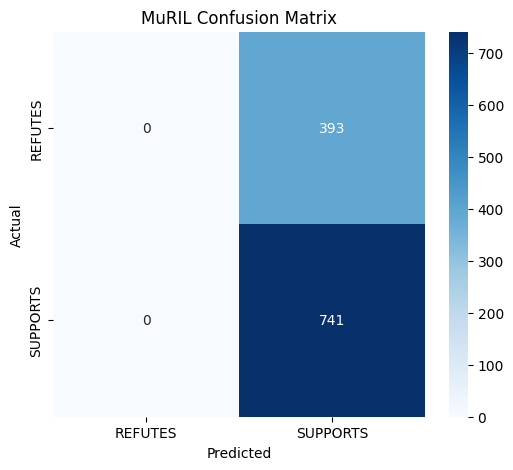

In [ ]:
cm = confusion_matrix(

    all_labels,

    all_predictions

)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=["REFUTES","SUPPORTS"],

    yticklabels=["REFUTES","SUPPORTS"]

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("MuRIL Confusion Matrix")

plt.show()

In [ ]:
#Plot training loss
plt.figure(figsize=(8,5))

plt.plot(

    history["train_loss"],

    marker="o",

    label="Training Loss"

)

plt.plot(

    history["val_loss"],

    marker="o",

    label="Validation Loss"

)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
#plot accuracyplt.figure(figsize=(8,5))

plt.plot(

    history["train_acc"],

    marker="o",

    label="Training Accuracy"

)

plt.plot(

    history["val_acc"],

    marker="o",

    label="Validation Accuracy"

)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
#plot F1 score
plt.figure(figsize=(8,5))

plt.plot(

    history["train_f1"],

    marker="o",

    label="Training F1"

)

plt.plot(

    history["val_f1"],

    marker="o",

    label="Validation F1"

)

plt.xlabel("Epoch")

plt.ylabel("F1 Score")

plt.title("Training vs Validation F1 Score")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# save Metrices
metrics = {

    "Accuracy": accuracy,

    "Precision": precision,

    "Recall": recall,

    "F1 Score": f1

}

metrics_df = pd.DataFrame(

    metrics,

    index=["MuRIL"]

)

metrics_df.to_csv(

    "/content/drive/MyDrive/FIRE2026/muril_metrics.csv",

    index=True

)

print(metrics_df)

       Accuracy  Precision  Recall  F1 Score
MuRIL  0.653439   0.653439     1.0    0.7904


In [ ]:
history_df = pd.DataFrame(history)

history_df.to_csv(

    "/content/drive/MyDrive/FIRE2026/muril_training_history.csv",

    index=False

)

print("Training history saved successfully!")

Training history saved successfully!


In [ ]:
print("Training Dataset")
print(train_df["label"].value_counts())

print("\nValidation Dataset")
print(dev_df["label"].value_counts())

Training Dataset
label
1    3040
0    1496
Name: count, dtype: int64

Validation Dataset
label
1    741
0    393
Name: count, dtype: int64


In [ ]:
for name, param in model.named_parameters():
    print(name, param.requires_grad)

muril.embeddings.word_embeddings.weight True
muril.embeddings.position_embeddings.weight True
muril.embeddings.token_type_embeddings.weight True
muril.embeddings.LayerNorm.weight True
muril.embeddings.LayerNorm.bias True
muril.encoder.layer.0.attention.self.query.weight True
muril.encoder.layer.0.attention.self.query.bias True
muril.encoder.layer.0.attention.self.key.weight True
muril.encoder.layer.0.attention.self.key.bias True
muril.encoder.layer.0.attention.self.value.weight True
muril.encoder.layer.0.attention.self.value.bias True
muril.encoder.layer.0.attention.output.dense.weight True
muril.encoder.layer.0.attention.output.dense.bias True
muril.encoder.layer.0.attention.output.LayerNorm.weight True
muril.encoder.layer.0.attention.output.LayerNorm.bias True
muril.encoder.layer.0.intermediate.dense.weight True
muril.encoder.layer.0.intermediate.dense.bias True
muril.encoder.layer.0.output.dense.weight True
muril.encoder.layer.0.output.dense.bias True
muril.encoder.layer.0.output.La

In [ ]:
batch = next(iter(train_loader))

print(batch["label"][:30])

tensor([0, 1, 1, 1, 1, 0, 0, 1])


In [ ]:
batch = next(iter(train_loader))

print(batch["input_ids"][0][:20])

tensor([   104,   1861,   1114,   2271, 131586,   1218,  32534,  60640,  13435,
           119,   1785,  30361,   1387,   1127,   1283,   3315,   6221,  26904,
          5596,   4813])
